In [2]:
from GWForge.population.mass import Mass
import numpy as np
import configparser

In [3]:
hyperpar_ini_file = 'pdb_hyperpar_defaults.ini'

In [4]:
cfg = configparser.ConfigParser()
# preserve key case from INI (case-sensitive keys)
cfg.optionxform = str
cfg.read(hyperpar_ini_file)
sec = cfg['hyperparameters']

# Load entire INI section as float-valued hyperparameters dictionary
hyperparams = {k: float(v) for k, v in sec.items()}
print("Loaded hyperparameters from INI file:", hyperparams)
hyperparams['mmin'] = 0.5
hyperparams['mmax'] = 350.0

Loaded hyperparameters from INI file: {'alpha_1': -4.509282643557759, 'alpha_dip': -1.6797692040029513, 'alpha_2': -0.9020346791414204, 'NSmin': 1.1763665089045245, 'NSmax': 4.094744137742966, 'BHmin': 7.7639549426962375, 'BHmax': 152.05597923492775, 'UPPERmin': 38.277415427531, 'UPPERmax': 66.57670527299628, 'n0': 50.0, 'n1': 50.0, 'n2': 50.0, 'n3': 30.0, 'n4': 30.0, 'n5': 10.041072204811995, 'mix1': 735.473275543081, 'mu1': 37.811196396328114, 'sig1': 17.12643064109277, 'mix2': 211.73332682799375, 'mu2': 8.897742041719734, 'sig2': 1.044692632025516, 'A': 0.091462424745936, 'A2': 0.8281652204882891, 'beta_pair_1': 0.9641379639323953, 'beta_pair_2': 2.160035650137072, 'mbreak': 5.0}


In [5]:
hyperparams.keys()

dict_keys(['alpha_1', 'alpha_dip', 'alpha_2', 'NSmin', 'NSmax', 'BHmin', 'BHmax', 'UPPERmin', 'UPPERmax', 'n0', 'n1', 'n2', 'n3', 'n4', 'n5', 'mix1', 'mu1', 'sig1', 'mix2', 'mu2', 'sig2', 'A', 'A2', 'beta_pair_1', 'beta_pair_2', 'mbreak', 'mmin', 'mmax'])

In [6]:
mass_model = Mass(mass_model='FullPop_GWTC4', 
                  number_of_samples=50000, 
                  parameters=hyperparams, 
                  max_iterations=10000)

In [7]:
mass_samples = mass_model.sample()

2026-02-10 02:15:23 Generating samples using fullpopgwtc4 model


Estimated maximum probability: 0.003387992175079073
Starting rejection sampling for 50000 samples...


Sampling: 100%|██████████| 50000/50000 [00:02<00:00, 19762.82samples/s]
2026-02-10 02:15:26 Rejection sampling acceptance rate: 0.0125


Sampling complete!
Generated 50001 samples (requested 50000)
Total proposals: 4010348
Acceptance rate: 0.0125


In [8]:
mass_samples

{'mass_1_source': array([ 8.87388791,  8.63110721,  2.24158165, ..., 36.68076248,
         9.39048399,  9.59074716]),
 'mass_2_source': array([ 8.13466252,  7.50552963,  1.7585335 , ..., 29.18342075,
         7.40389426,  6.10433907]),
 'chirp_mass_source': array([ 7.39500764,  7.00335446,  1.72587217, ..., 28.44558493,
         7.24863321,  6.62738062]),
 'total_mass_source': array([17.00855043, 16.13663684,  4.00011515, ..., 65.86418323,
        16.79437826, 15.69508624]),
 'symmetric_mass_ratio': array([0.24952776, 0.24878363, 0.24635434, ..., 0.24676066, 0.24650193,
        0.23766415]),
 'mass_ratio': array([0.91669656, 0.86959059, 0.78450567, ..., 0.79560562, 0.7884465 ,
        0.63648212])}

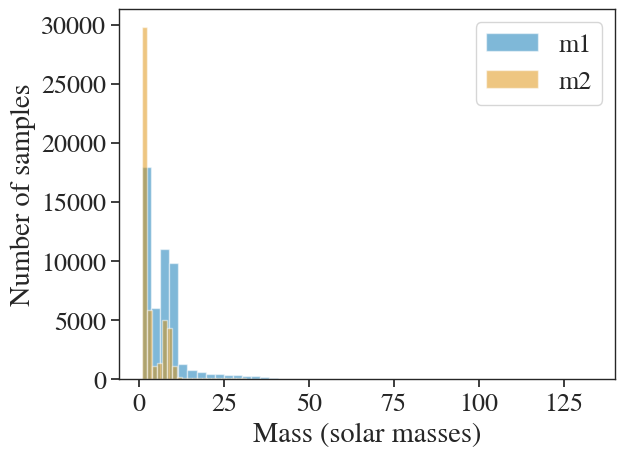

In [9]:
import pylab as plt
plt.hist(mass_samples['mass_1_source'], bins=50, alpha=0.5, label='m1')
plt.hist(mass_samples['mass_2_source'], bins=50, alpha=0.5, label='m2')
plt.xlabel('Mass (solar masses)')
plt.ylabel('Number of samples')
plt.legend()